In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
from gates.plotting import plot_fp_predictions

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [5]:
preds = xr.open_dataset("/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/test_predictions/fixedmet_gpu_freq3_PixelWeightedMSELoss_a1_landcover/predictions/predictions_2016_12.nc")

[1, 1]


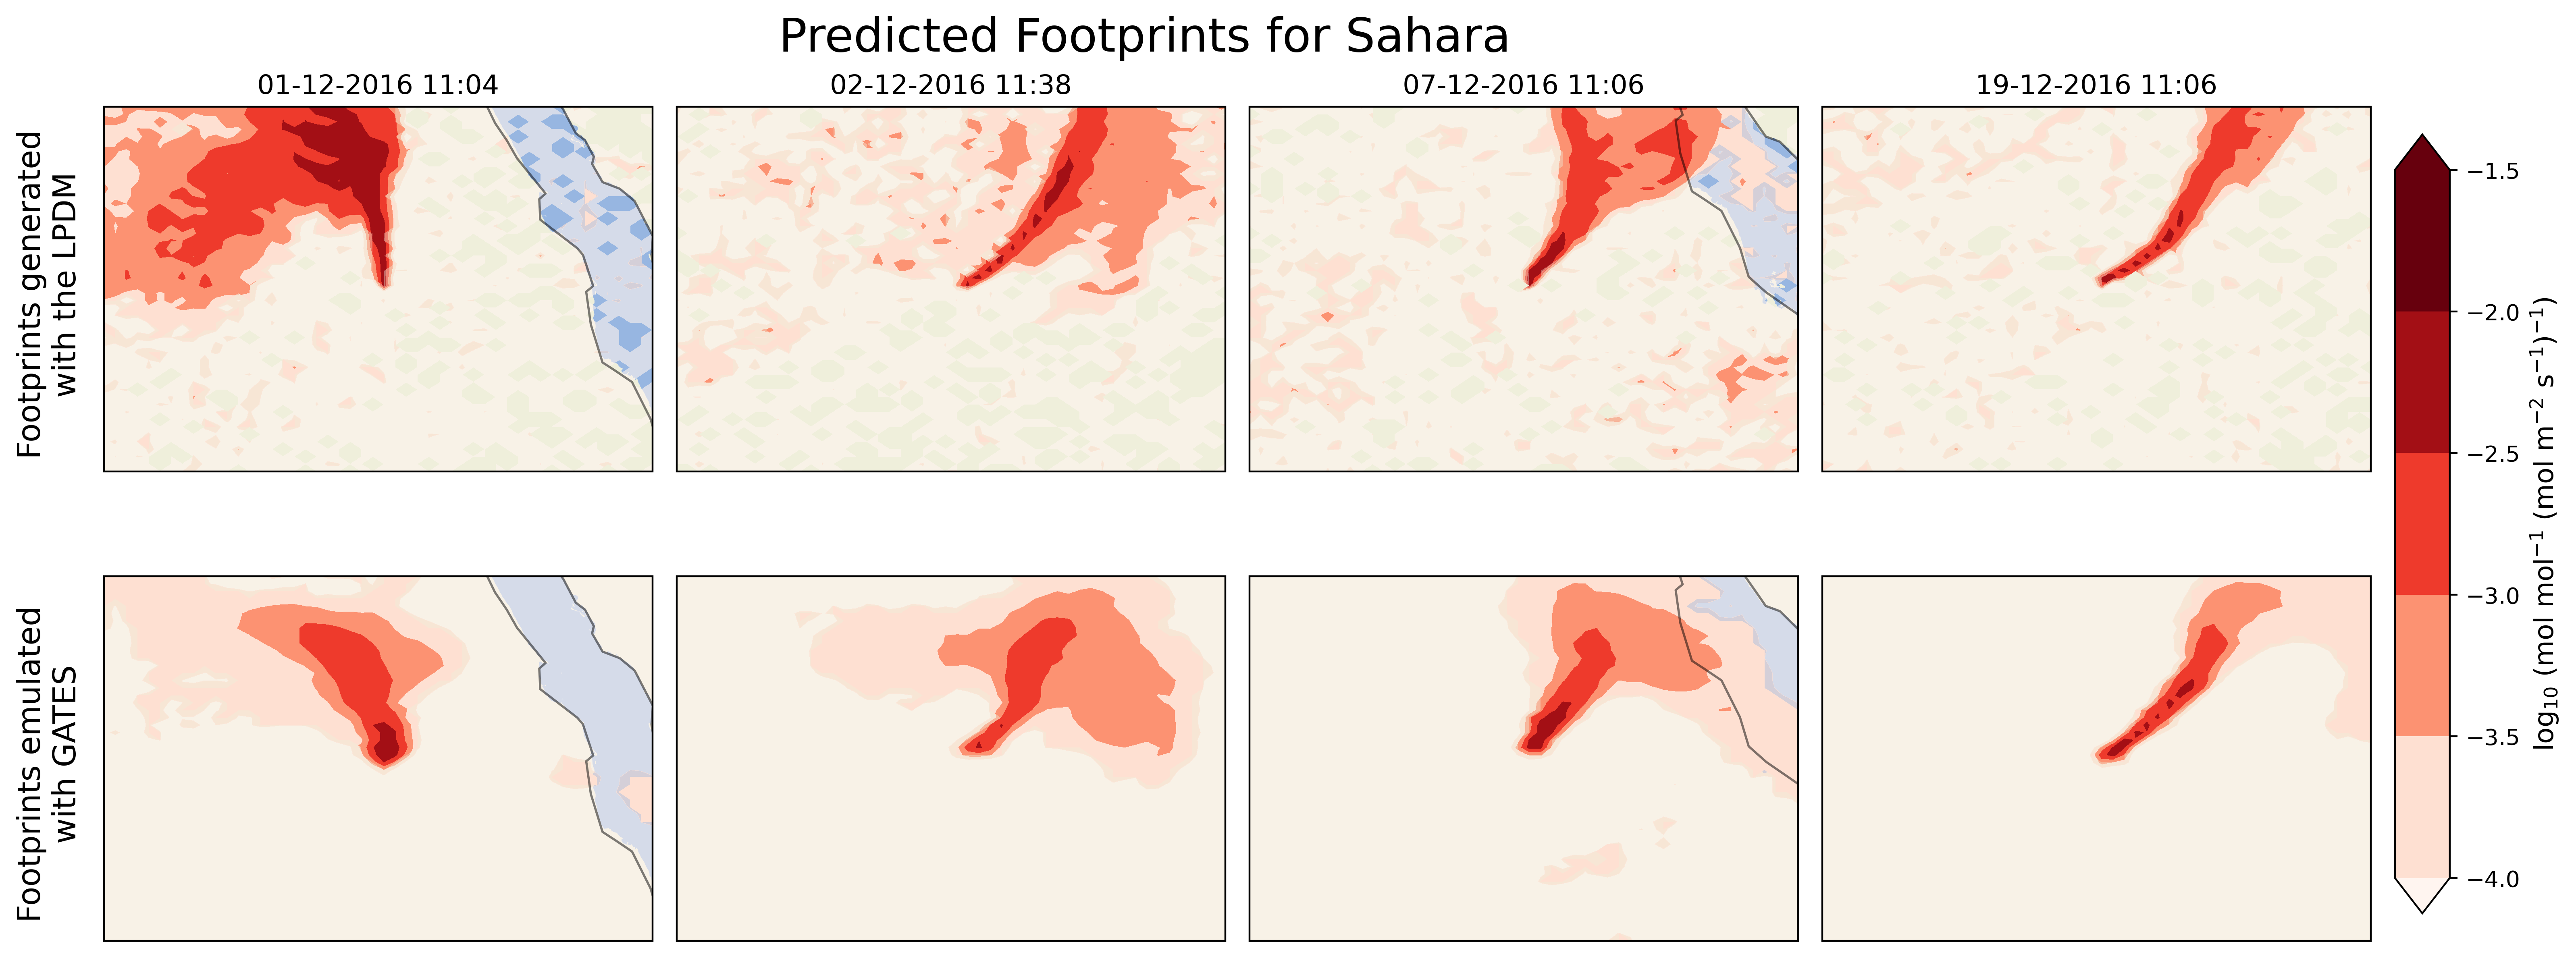

In [6]:
## plot footprints with this function. specify the index of the footprints to plot as a list in idxs_list (the length can be variable). Contour is recommended, you can override the levels and the min/max with levels and vmin_vmax arguments. The threshold parameter is used in the contour - anything below the threshold is set as a lighter, see-through colour. 
plot_fp_predictions(preds, idxs_list=[10, 100, 300, 800], contour=True, thres=1e-4, fig_title="Predicted Footprints for Sahara", which_dataspace="original")

In [9]:
from gates.data.load_data import load_flux_data, cut_flux_data
from gates.evaluation.post_processing import threshold_fps
import gates.evaluation.metrics as gates_metrics

In [10]:
# threshold the predicted footprints to a determined threshold  
preds = threshold_fps(preds, threshold=1.75e-5)

[1, 1]


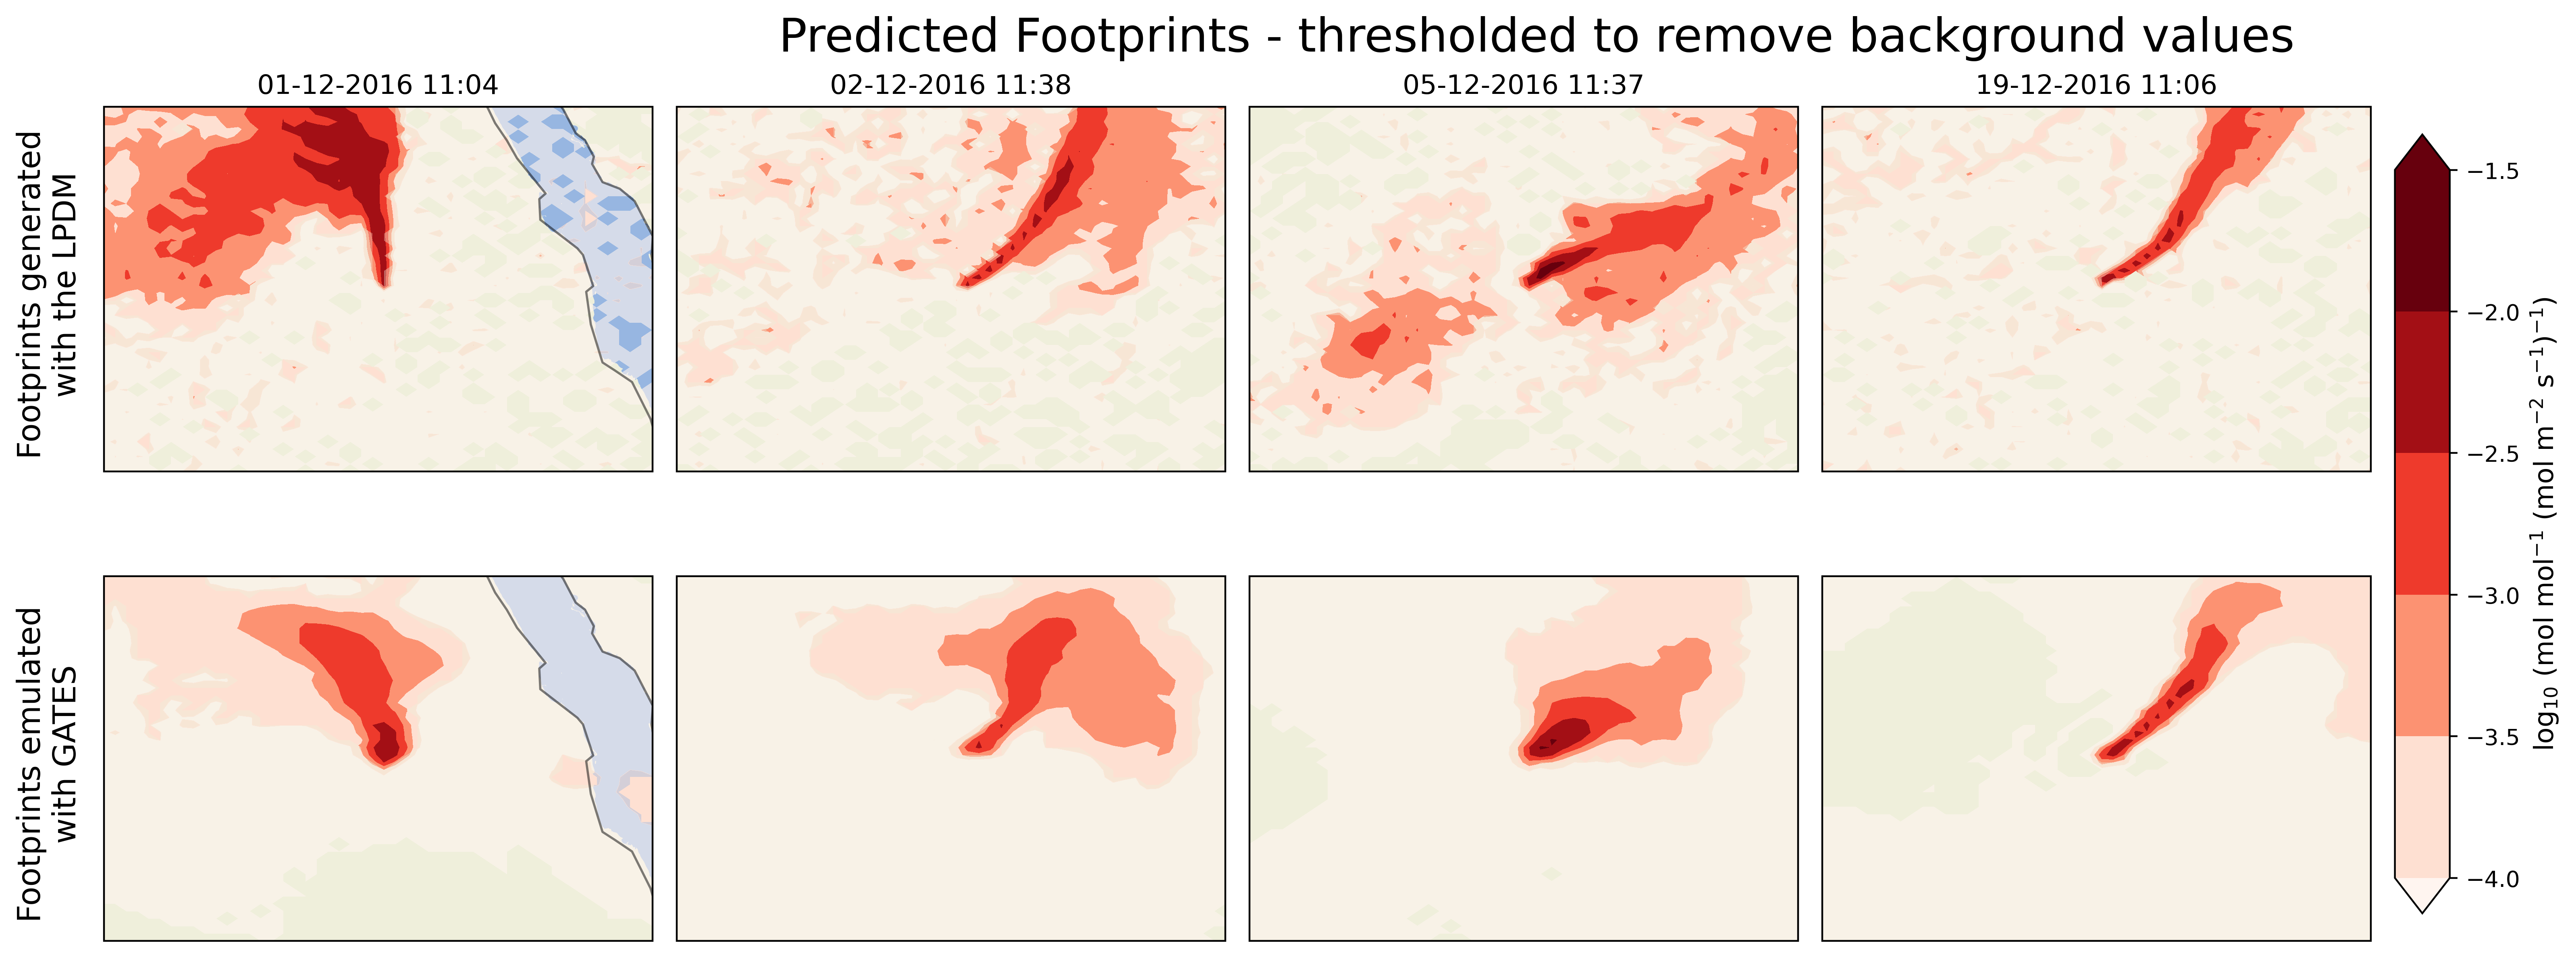

In [12]:
# and plot them
plot_fp_predictions(preds, idxs_list=[10, 100, 200, 800], contour=True, thres=1e-4, fig_title="Predicted Footprints - thresholded to remove background values", which_dataspace="thresholded")

In [30]:
# you can plot some stats about the footprints with
gates_metrics.compute_footprint_metrics(preds["fp_original"], preds["fp_pred_thres"], ignore_mask=preds["fp_nan_mask"])

{'iou': 0.6813649722854264,
 'mse': 3.5517493301995273e-07,
 'mae': 0.00016755287651903927,
 'nmae': 0.8864462971687317,
 'corrcoef': 0.6554632921502989,
 'corrcoef_log': 0.5404692415459786,
 'bias': -7.736408588243648e-05}

In [32]:
import gates

In [40]:
# you can also load the fluxes, crop them and calculate the mole fractions
ems = load_flux_data("NORTHAFRICA", year=2016)
cropped_fluxes, _ = cut_flux_data(ems, preds, size=50)
mfs = gates_metrics.calculate_mfs(preds[["fp_original", "fp_pred_thres"]], cropped_fluxes, transform_factor=1e9)

Loading flux data from /group/chem/acrg/LPDM/emissions/NORTHAFRICA/ch4_NORTHAFRICA_2016.nc
cut_flux_data: WARNING — flux resolution (0.2340, 0.3520) differs from fp resolution (1.0000, 1.0000). Spatial alignment may be off.
Using lat_coords and lon_coords to cut flux data, assuming they are aligned and have the same resolution as the flux data.


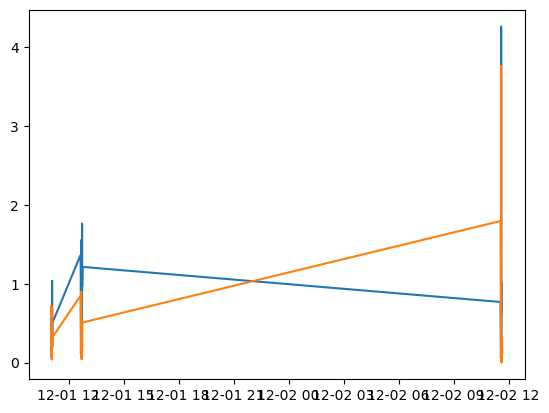

In [61]:
# we can plot these (new functions coming)
plt.plot(mfs["mf_original"].isel(time=slice(0,100)).time, mfs["mf_original"].isel(time=slice(0,100)))
plt.plot(mfs["mf_pred_thres"].isel(time=slice(0,100)).time, mfs["mf_pred_thres"].isel(time=slice(0,100)))

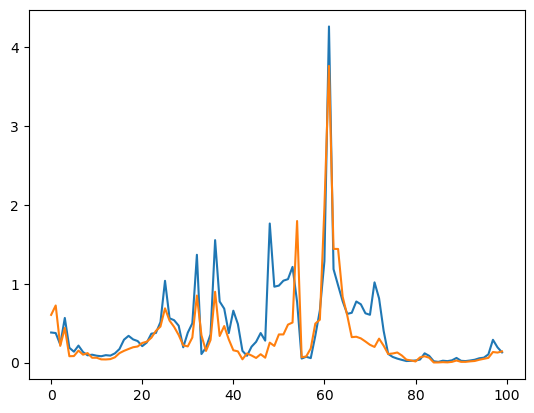

In [ ]:
# we can plot these (new functions coming)
plt.plot(mfs["mf_original"].isel(time=slice(0,100)).values)
plt.plot(mfs["mf_pred_thres"].isel(time=slice(0,100)).values)

In [45]:
# and get some metrics
gates_metrics.compute_mfs_metrics(mfs["mf_original"], mfs["mf_pred_thres"])

{'corrcoef': 0.7997281586305034,
 'mae': 0.3363400995731354,
 'mean_bias': -0.2613910138607025,
 'true_mean': 0.7008071541786194,
 'predicted_mean': 0.4394161105155945,
 'r2_score': 0.5422990322113037}

In [ ]:
# and compute metrics using uniform fluxes
gates_metrics.compute_static_mf_metrics(preds["fp_original"], preds["fp_pred_thres"], ignore_mask=preds["fp_nan_mask"])

{'uniform': {'corrcoef': 0.662377000764233,
  'mae': 0.20506483234041042,
  'mean_bias': -0.1930486263981564,
  'true_mean': 0.5005686759948731,
  'predicted_mean': 0.30752004959671664,
  'r2_score': -0.1495677476362991},
 'checkerboard': {'corrcoef': 0.6641080550544338,
  'mae': 0.10131603726918854,
  'mean_bias': -0.09510897798840574,
  'true_mean': 0.24953370094299315,
  'predicted_mean': 0.15442472295458742,
  'r2_score': -0.1299293924477385},
 'checkerboard_10': {'corrcoef': 0.5879137280236607,
  'mae': 0.1045702502375363,
  'mean_bias': -0.09873520504572611,
  'true_mean': 0.22677549123764038,
  'predicted_mean': 0.12804028619191427,
  'r2_score': -0.29310108975733895},
 'checkerboard_25': {'corrcoef': 0.740069475387015,
  'mae': 0.09323803794650871,
  'mean_bias': -0.07748282112802088,
  'true_mean': 0.1912314236164093,
  'predicted_mean': 0.11374860248838843,
  'r2_score': 0.31260759760973933}}

## plotting sample predictions

# this is a bit hacky, but you can visualise sample predictions generated during model training as follows

In [ ]:
preds = xr.open_dataset("/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/test_jobs/fixedmet_gpu_freq3_PixelWeightedMSELoss_a1_landcover_20260428_085335/sample_predictions_test.nc")

In [83]:
from gates.config import get_config
from gates.data.load_data import load_fps, cut_satellite_data
cfg = get_config()


In [ ]:
# load the footprints for the same time period as the predictions, and crop them to the same spatial extent (this is needed to get the lat/lon coordinates for plotting)
fps = load_fps(cfg.fp_datadir / "NORTHAFRICA" / "GOSAT*2016*", verbose=True)
fps_subset = fps.sel(time=preds.time)
fps_cropped = cut_satellite_data(fps_subset, size=50)[0]
# then extract the lat/lon coordinates for the cropped area, needed for plotting
preds["lat_coords"] = fps_cropped["lat_coords"]
preds["lon_coords"] = fps_cropped["lon_coords"]

WITH CHUNKING -
there was an error opening the dataset. checking if any of the files are in the bad files list
at least one of the files was in the bad files list, opening with workaround
loading bad file with workaround: /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/GOSAT-SAHARA-column_NORTHAFRICA_201609.nc
loading bad file with workaround: /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/GOSAT-SAHARA-column_NORTHAFRICA_201610.nc
loading bad file with workaround: /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/GOSAT-SAHARA-column_NORTHAFRICA_201612.nc
Padding lat by (0, 11) cells (S, N) with mode='nans'


[1, 1]


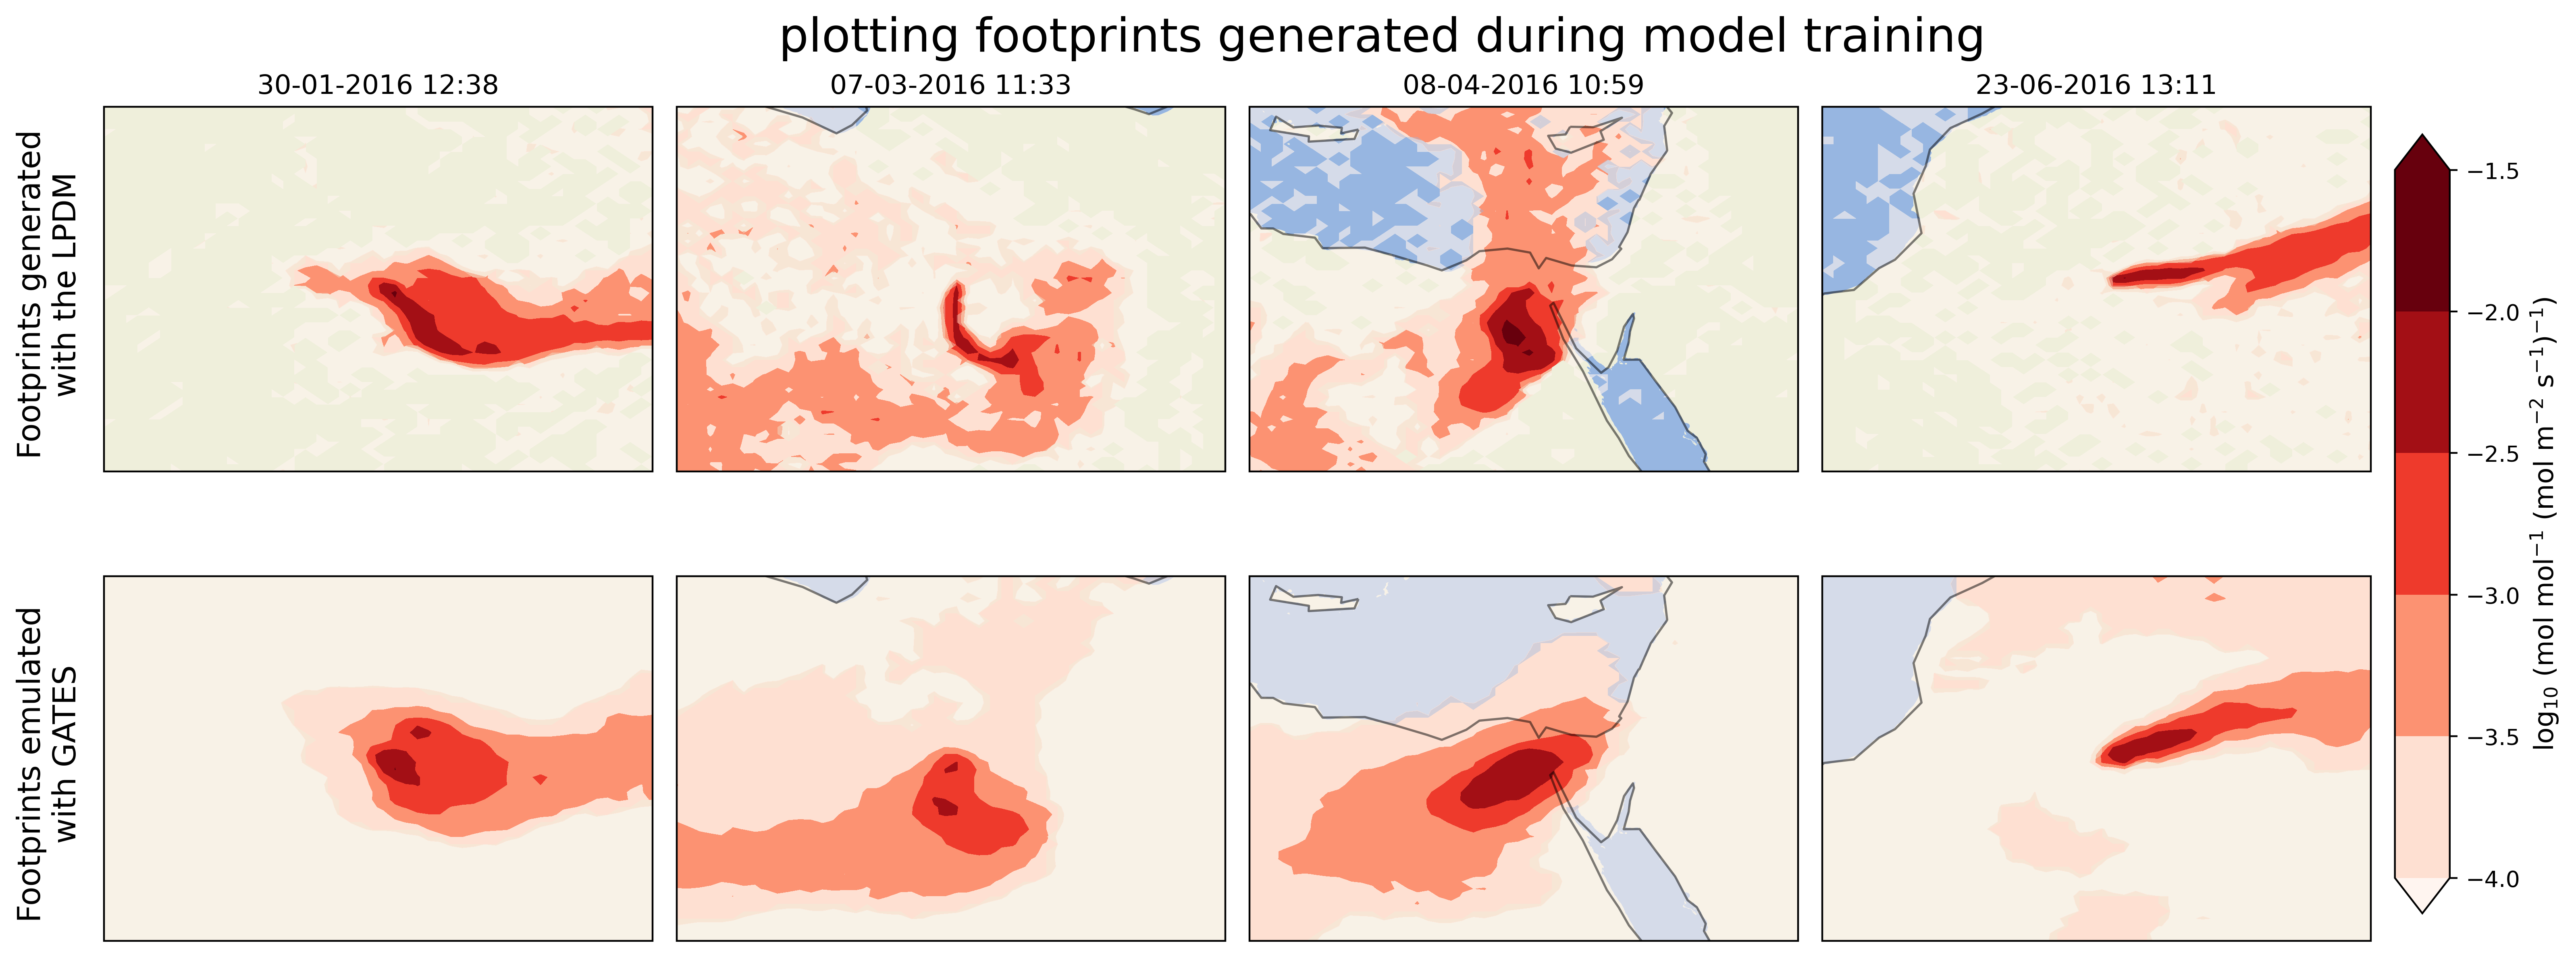

In [ ]:
# now you can plot
plot_fp_predictions(preds, idxs_list=[10, 23, 33, 56], contour=True, thres=1e-4, fig_title="plotting footprints generated during model training", which_dataspace="original")

## across region

In [52]:
preds = xr.open_dataset("/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/test_predictions/fixedmet_gpu_freq3_PixelWeightedMSELoss_a1_landcover/predictions_BRAZIL/predictions_2016_11.nc")

[1, 1]


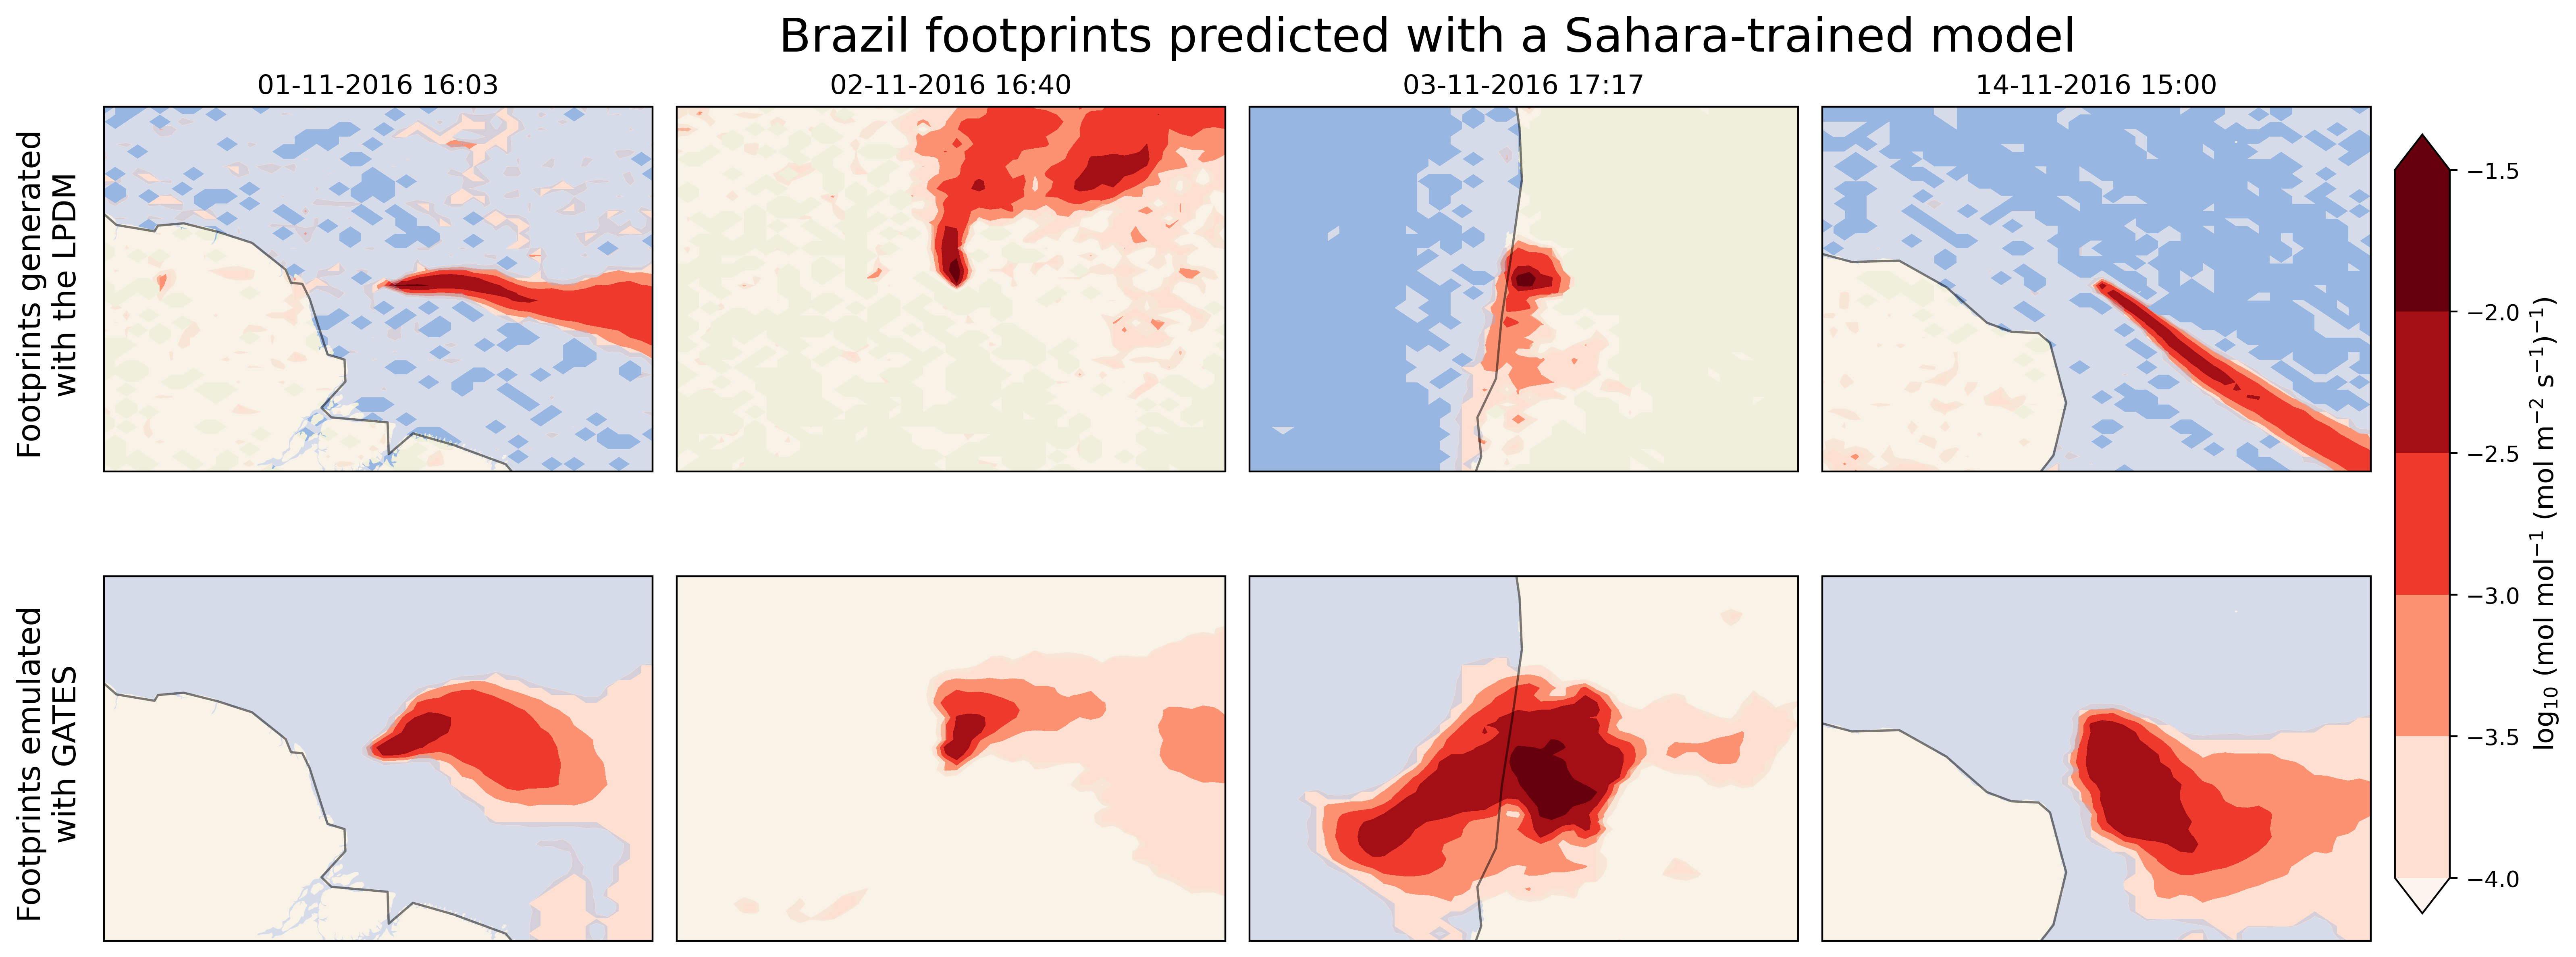

In [53]:
# and plot them
plot_fp_predictions(preds, idxs_list=[10, 100, 200, 800], contour=True, thres=1e-4, fig_title="Brazil footprints predicted with a Sahara-trained model", which_dataspace="original")